# Données hydrographiques (HydroRIVERS)

`Hydro` télécharge le jeu **HydroRIVERS v10** (HydroSHEDS) : le réseau
hydrographique mondial vectorisé, avec pour chaque tronçon la longueur, le
débit moyen, l'ordre de Strahler, la surface du bassin versant, etc.

Les données sont fournies **par continent** : `af`, `as`, `au`, `eu`,
`na`, `sa`. On télécharge une fois, puis on filtre à sa zone d'étude.

> Le fichier Afrique fait ~150 Mo (≈ 1,3 M de tronçons). Premier appel long ;
> ensuite servi depuis `_hydro_cache/`.

In [1]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # cartograpy est à la racine du dépôt
logging.basicConfig(level=logging.INFO, format="%(message)s")

import geopandas as gpd
import cartograpy as cp
from cartograpy.data import Hydro, Bound

hy = Hydro()

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


In [2]:
print(hy.describe_variables())


    📘 Description des variables HydroRIVERS :
| Nom          | Signification                    | Unité / Type         |
| ------------ | -------------------------------- | -------------------- |
| `HYRIV_ID`   | ID du tronçon                    | entier               |
| `NEXT_DOWN`  | ID du tronçon aval               | entier               |
| `MAIN_RIV`   | ID du fleuve principal           | entier               |
| `LENGTH_KM`  | Longueur du segment              | km (float)           |
| `DIST_DN_KM` | Distance jusqu'à l'embouchure    | km (float)           |
| `DIST_UP_KM` | Distance depuis la source        | km (float)           |
| `CATCH_SKM`  | Surface locale du bassin versant | km² (float)          |
| `UPLAND_SKM` | Surface totale en amont          | km² (float)          |
| `ENDORHEIC`  | 1 = bassin fermé, 0 = ouvert     | booléen (int)        |
| `DIS_AV_CMS` | Débit moyen                      | m³/s (float)         |
| `ORD_STRA`   | Ordre de Strahler                | e

## Télécharger un continent

In [3]:
rivers = hy.download("af", output_dir="_hydro_cache")
print(f"{len(rivers):,} tronçons")
rivers[["HYRIV_ID", "LENGTH_KM", "DIS_AV_CMS", "ORD_STRA", "UPLAND_SKM", "geometry"]].head()

Téléchargement des données HydroRIVERS pour la région : AF ...


Téléchargement et extraction terminés.


1,527,551 tronçons


,HYRIV_ID,LENGTH_KM,DIS_AV_CMS,ORD_STRA,UPLAND_SKM,geometry
0,10000001,0.89,0.062,1,11.1,"LINESTRING (9.6625 37.325, 9.65625 37.33125)"
1,10000002,2.90,0.126,1,24.2,"LINESTRING (9.8 37.30833, 9.81042 37.31875, 9...."
2,10000003,4.63,0.316,1,57.2,"LINESTRING (9.68542 37.27083, 9.68542 37.26458..."
3,10000004,0.69,0.061,1,11.1,"LINESTRING (9.71458 37.2375, 9.71458 37.24375)"
4,10000005,8.32,0.177,1,34.0,"LINESTRING (9.75 37.27708, 9.75625 37.27708, 9..."


## Filtrer à une zone d'étude

On réduit d'abord à la bounding box (indexeur `.cx`, rapide), puis on
découpe exactement à la frontière.

In [4]:
civ = Bound().get_country("CIV").set_crs("EPSG:4326")
w, s, e, n = civ.total_bounds

civ_rivers = gpd.clip(rivers.cx[w:e, s:n], civ)
print(f"{len(civ_rivers):,} tronçons en Côte d'Ivoire")
civ_rivers["ORD_STRA"].value_counts().sort_index()

19,378 tronçons en Côte d'Ivoire


ORD_STRA
1    9773
2    4444
3    2234
4    1287
5     882
6     692
7      66
Name: count, dtype: int64

## Carte : hiérarchie du réseau

L'ordre de Strahler (`ORD_STRA`) classe les tronçons du ruisseau (1) au
fleuve (élevé). On épaissit le trait avec l'ordre.

🧭 Flèche du Nord ajoutée (map-utils)


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.96


   Étendue: [-11.02, -0.11, 3.90, 11.17]


C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


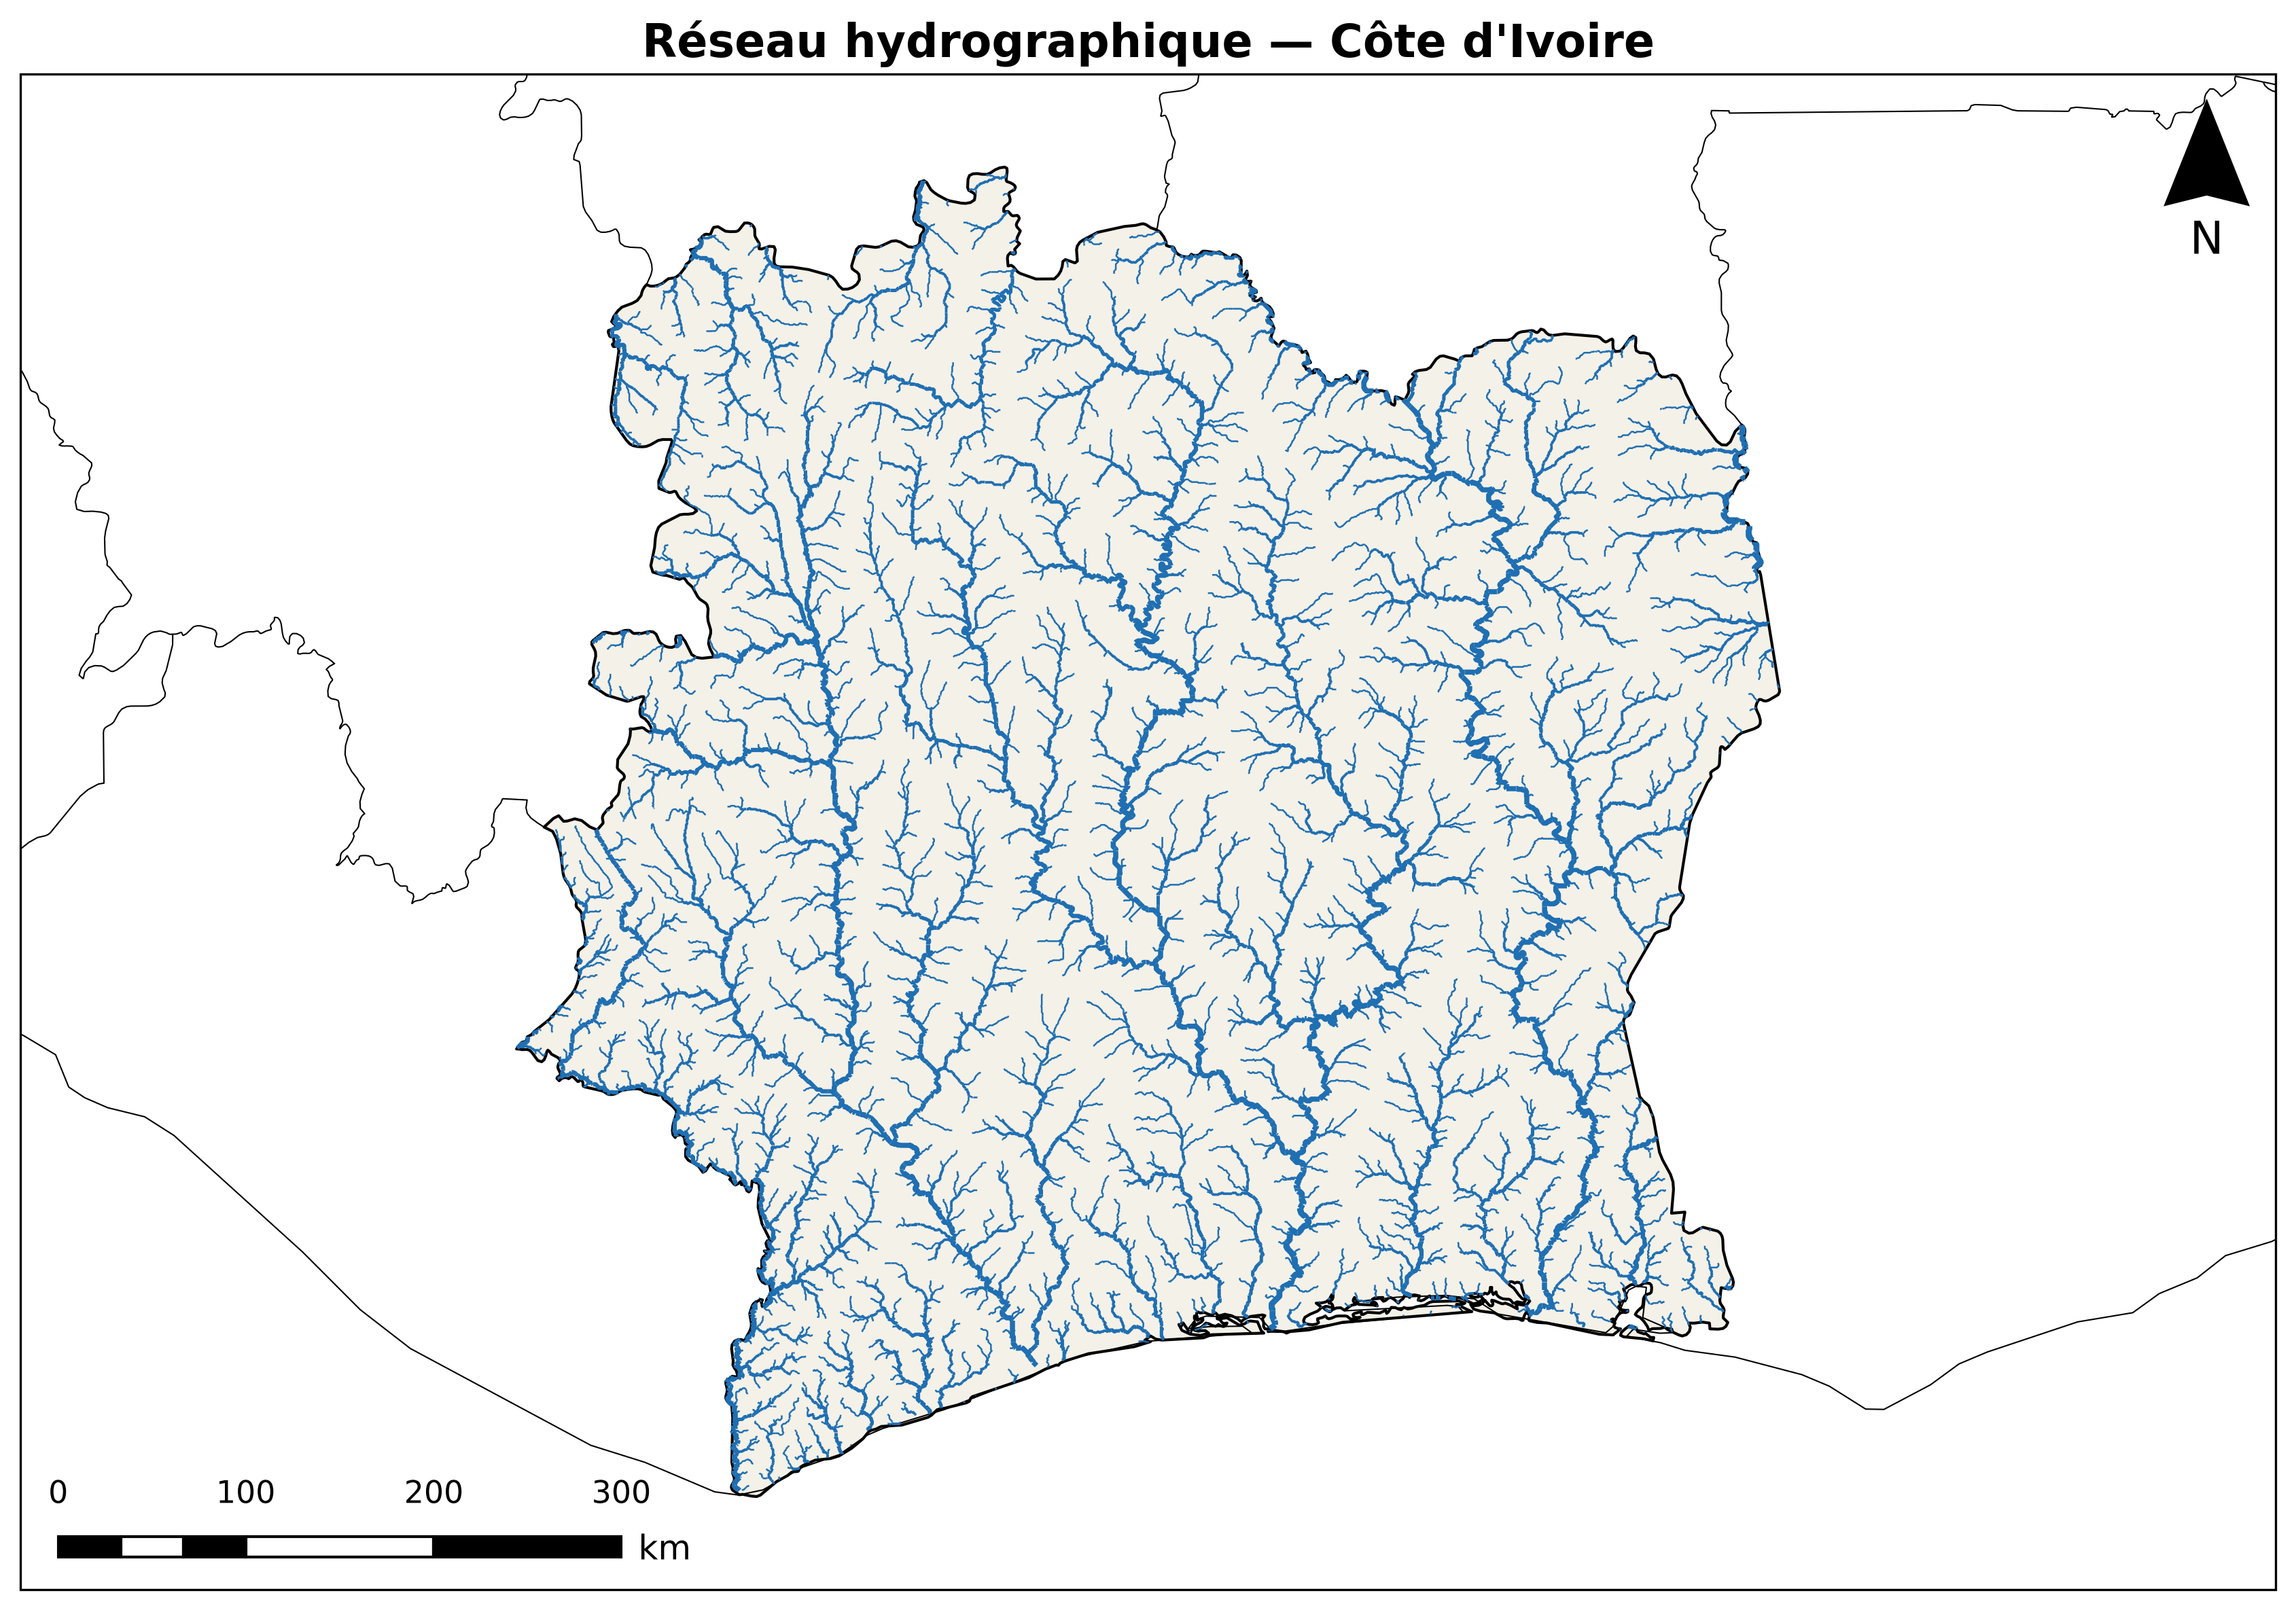

In [5]:
m = cp.Map(title="Réseau hydrographique — Côte d'Ivoire")
m.add_polygons(civ, facecolor="#f4f1e8", edge_color="black", alpha=1)

for ordre in range(2, int(civ_rivers["ORD_STRA"].max()) + 1):
    couche = civ_rivers[civ_rivers["ORD_STRA"] == ordre]
    if couche.empty:
        continue
    m.add_lines(couche, color="#1f6fb2", linewidth=0.3 * ordre)

m.add_north_arrow()
m.add_scale_bar()
m.show()

## Carte : débit moyen

`DIS_AV_CMS` = débit moyen (m³/s). On ne garde que les cours d'eau
significatifs et on colore par le débit.

📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.96


   Étendue: [-11.02, -0.11, 3.90, 11.17]


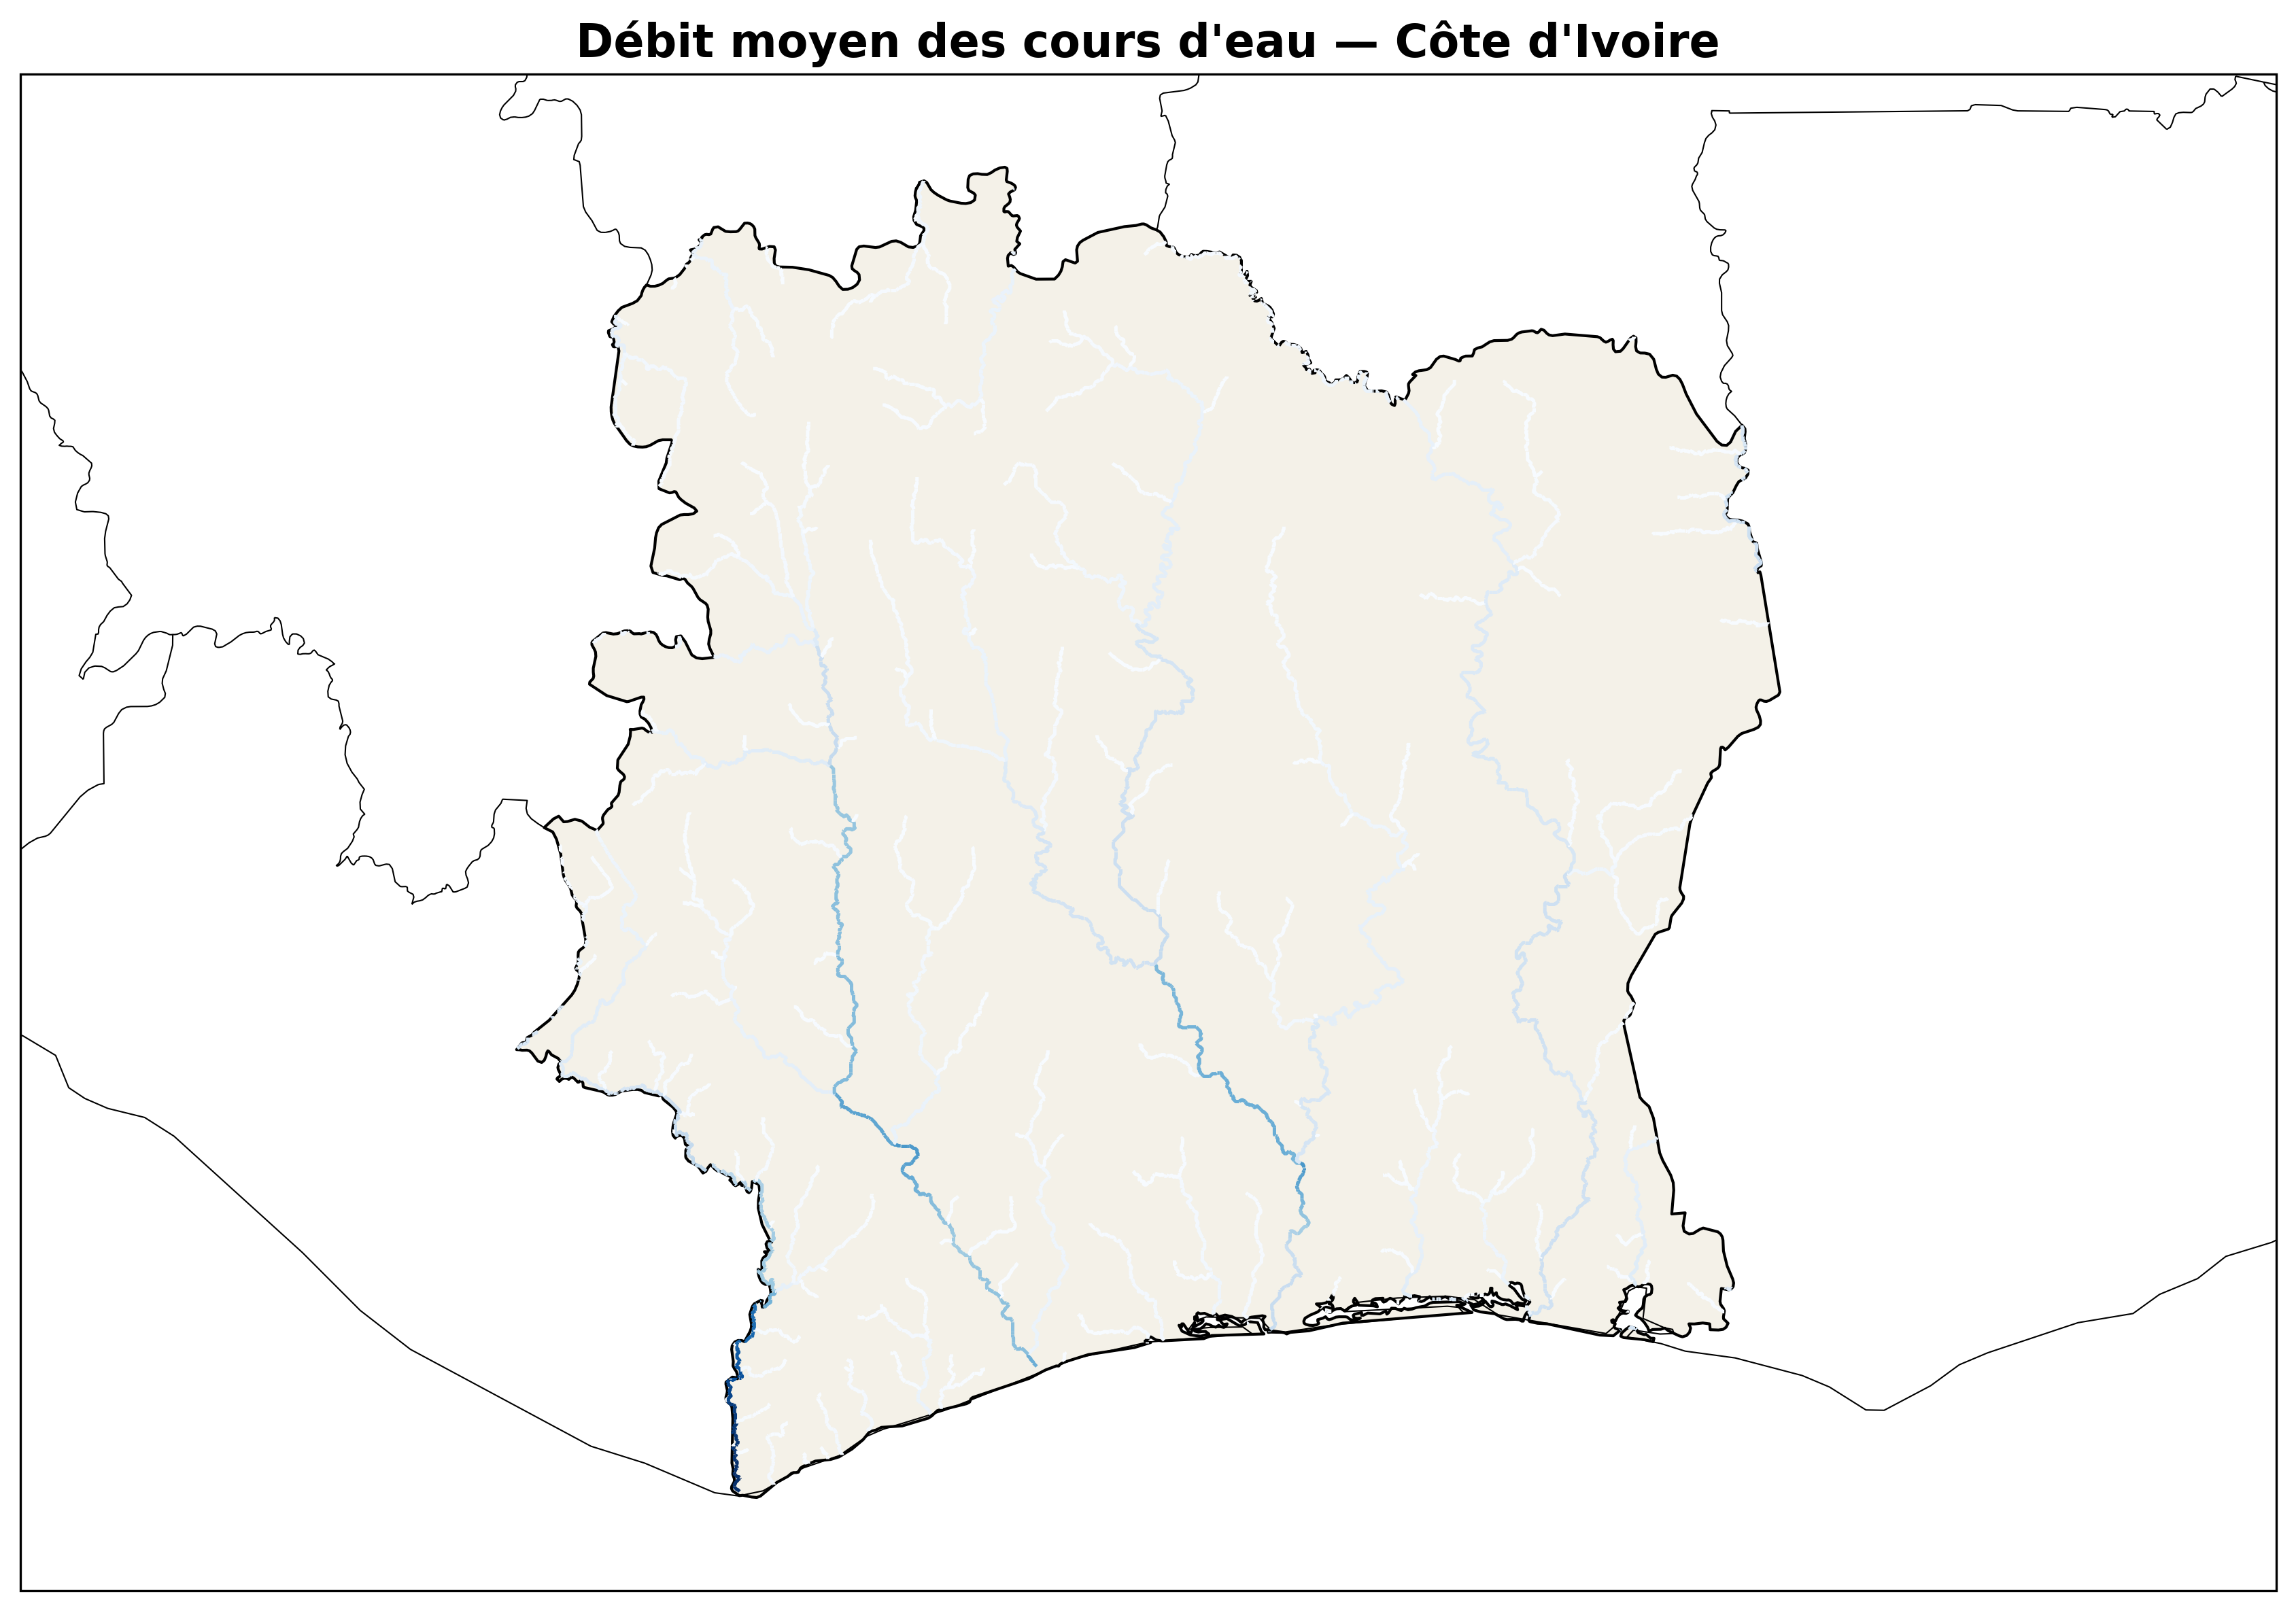

In [6]:
axes = civ_rivers[civ_rivers["DIS_AV_CMS"] > 5].copy()

m = cp.Map(title="Débit moyen des cours d'eau — Côte d'Ivoire")
m.add_polygons(civ, facecolor="#f4f1e8", edge_color="black", alpha=1)
m.add_lines(axes, column="DIS_AV_CMS", cmap="Blues", linewidth=1.2)
m.show()

## Le plus long fleuve de la zone

`MAIN_RIV` regroupe les tronçons d'un même fleuve ; `LENGTH_KM` donne la
longueur de chacun.

Top 5 fleuves (km cumulés de tronçons dans la zone) :
MAIN_RIV
10850962    21755.38
10857729    15809.93
10848636    14215.15
10878253     5739.33
10877687     5552.03
Name: LENGTH_KM, dtype: float64


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.96


   Étendue: [-11.02, -0.11, 3.90, 11.17]


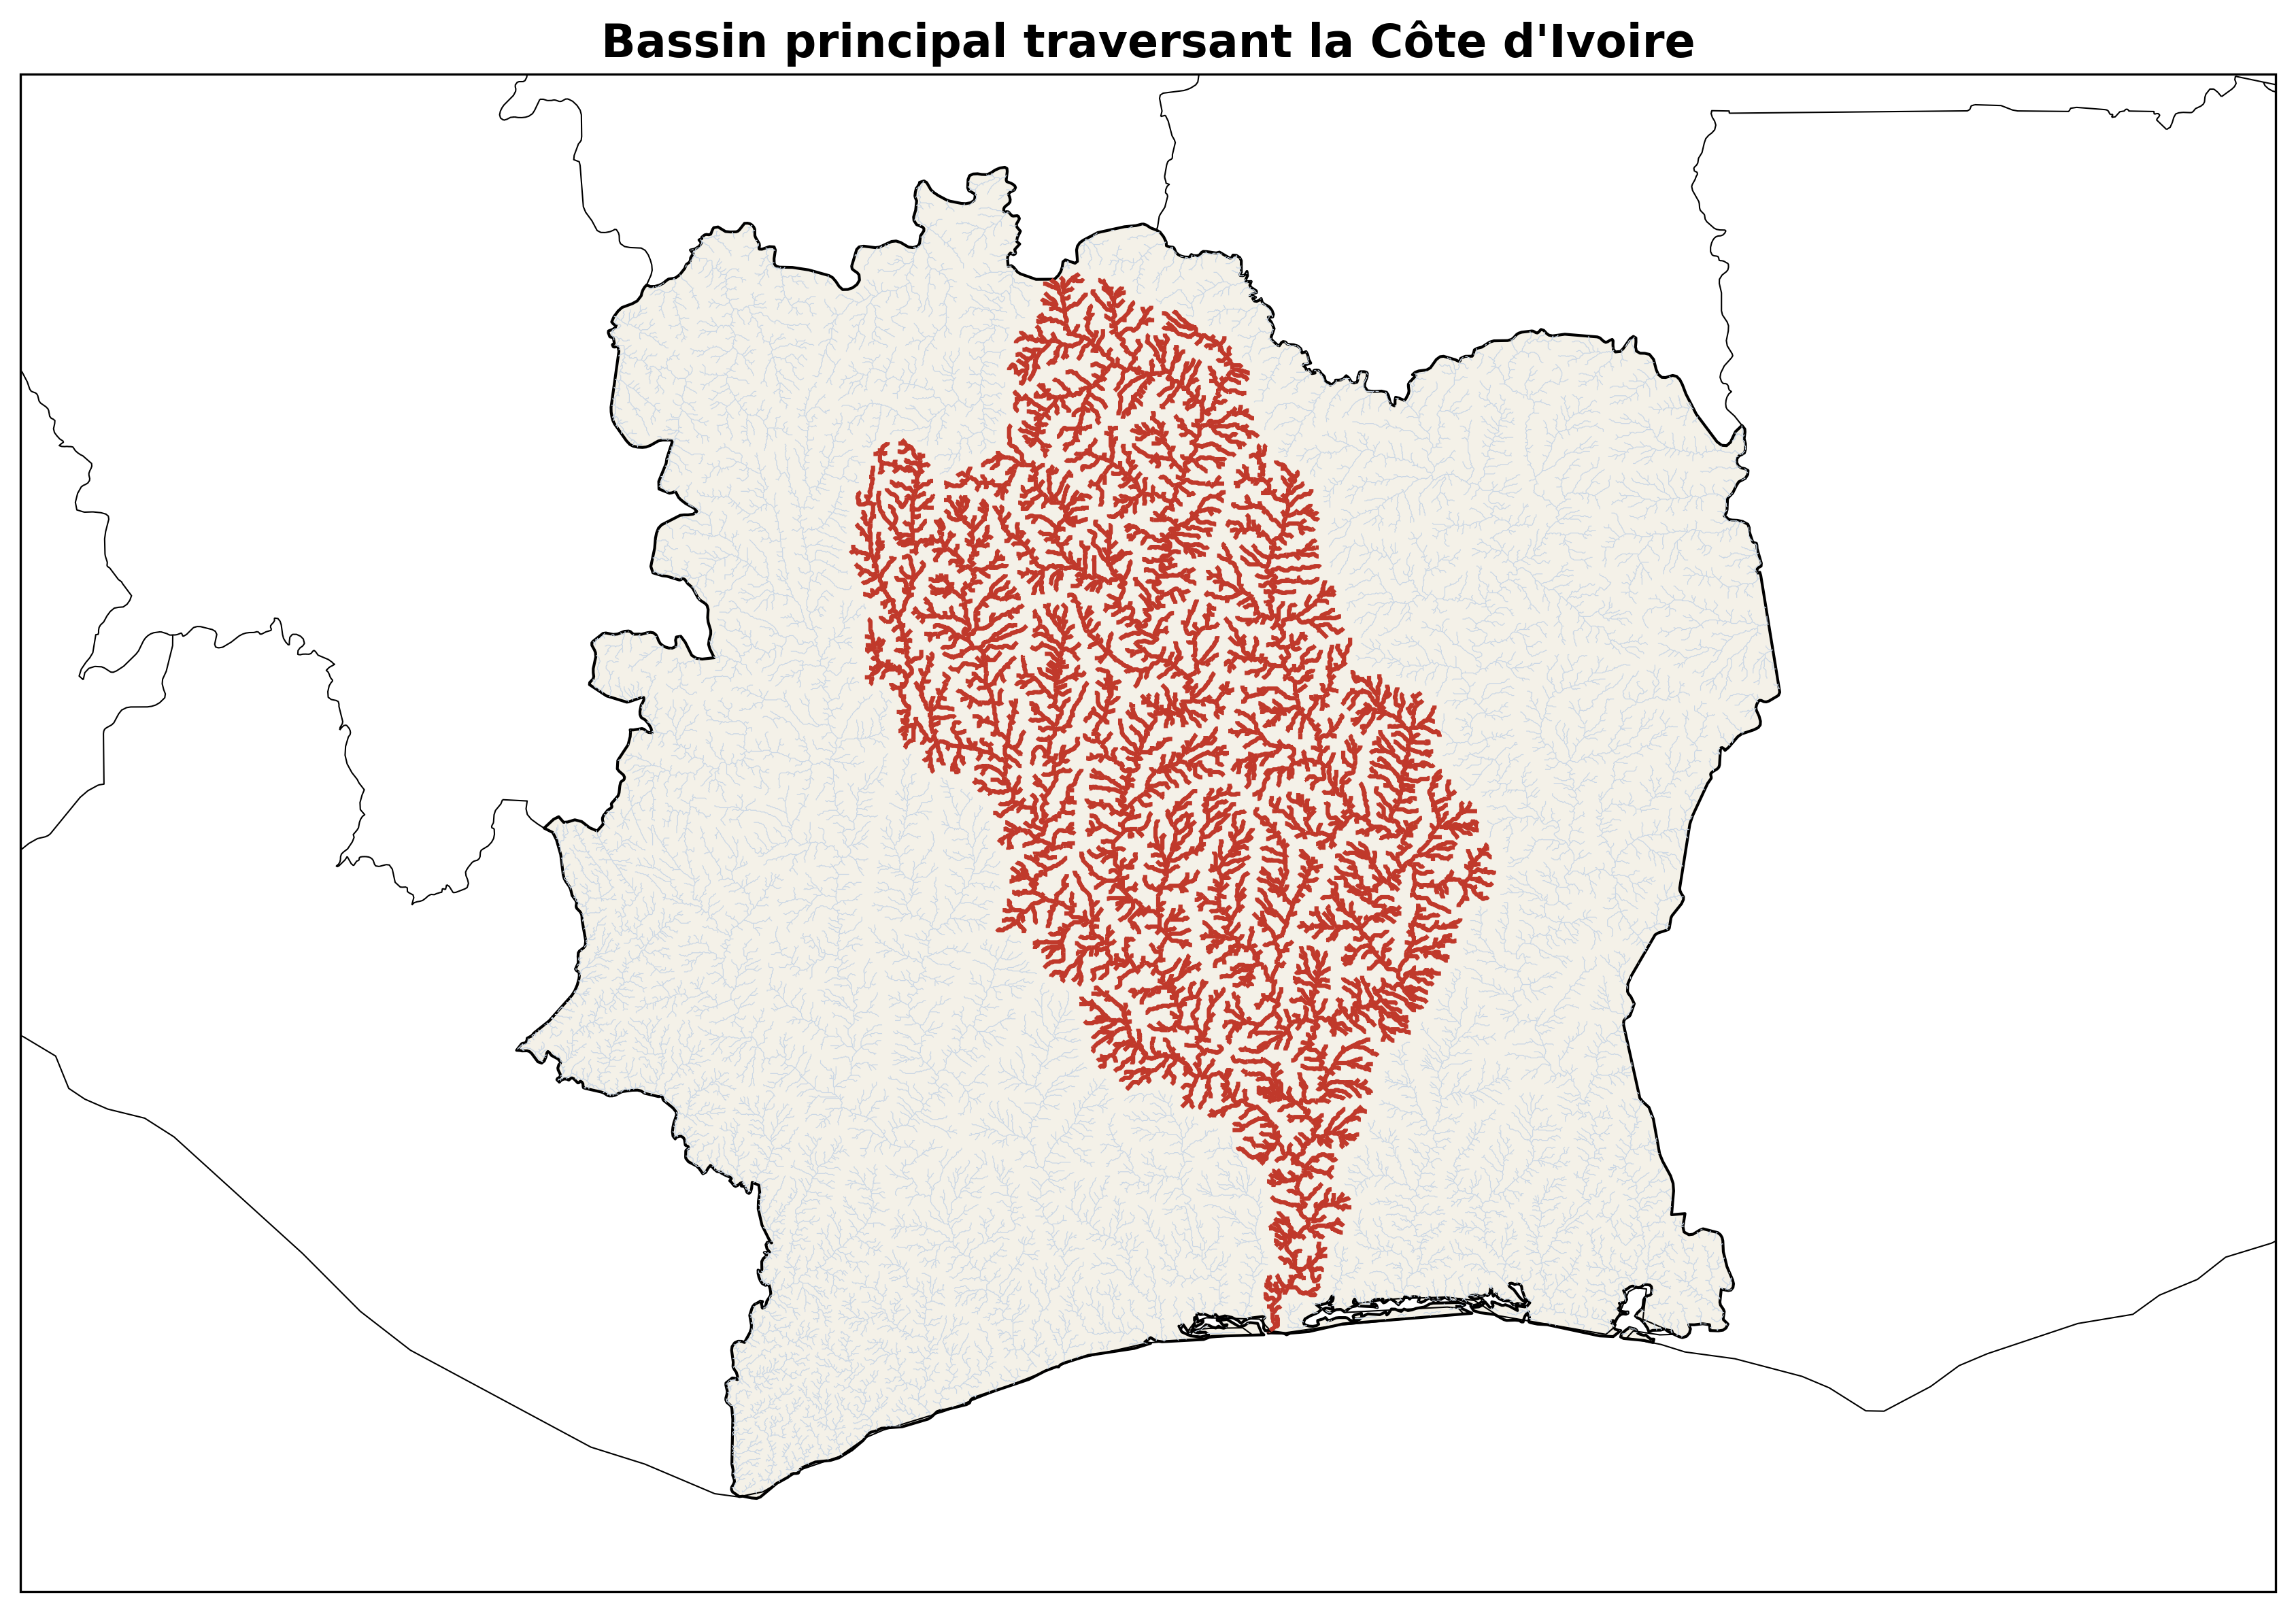

In [7]:
par_fleuve = civ_rivers.groupby("MAIN_RIV")["LENGTH_KM"].sum().sort_values(ascending=False)
print("Top 5 fleuves (km cumulés de tronçons dans la zone) :")
print(par_fleuve.head())

principal = civ_rivers[civ_rivers["MAIN_RIV"] == par_fleuve.index[0]]

m = cp.Map(title="Bassin principal traversant la Côte d'Ivoire")
m.add_polygons(civ, facecolor="#f4f1e8", edge_color="black", alpha=1)
m.add_lines(civ_rivers, color="#c9d6e5", linewidth=0.3)
m.add_lines(principal, color="#c0392b", linewidth=1.5)
m.show()

## Enregistrer le sous-ensemble

Pour ne pas recharger tout le continent la prochaine fois.

In [8]:
from cartograpy.data import save

save(civ_rivers, "gpkg", filename="_hydro_cache/rivers_civ")

Created 19,378 records


✅ Fichier sauvegardé : C:\Users\Ordinateur\OneDrive\cartograpy\notebooks\_hydro_cache\rivers_civ.gpkg


'C:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\_hydro_cache\\rivers_civ.gpkg'

## Petite zone : préférer OpenStreetMap

Pour une ville ou un bassin local, `OSM` évite de télécharger tout un
continent (voir le notebook 4).

In [9]:
from cartograpy.data import OSM

cours_deau = OSM().get_data(
    "Yamoussoukro, Côte d'Ivoire",
    {"waterway": ["river", "stream", "canal"], "natural": "water"},
    data_type="all",
)
print(len(cours_deau), "objets hydrographiques (OSM)")

388 objets hydrographiques (OSM)
